In [1]:
import pandas as pd
df = pd.read_csv('sales_merge.csv', index_col=2, parse_dates=True)
df = df.iloc[:, 1:]
df

,기간,라인,성별,기획년도,시즌이월,상품년차,시즌,복종,소품종,CAT,...,매장재고택가,재고수량,재고원가,재고택가,기간입고수량,기간입고원가,기간입고택가,기간출고수량,기간출고원가,기간출고택가
주차,,,,,,,,,,,,,,,,,,,,,
2022-01-02,당해,ZB,1:남성,2022,01_시즌,당해년도,봄,수트,블레이져(수트),09_SUITS,...,333405000,2394,101038588,572166000,0,0,0,27,1139533,6453000
2022-01-02,당해,ZB,1:남성,2022,01_시즌,당해년도,사계절,팬츠,팬츠(일반),04_PANTS,...,1472026500,32926,335862766,3289307400,0,0,0,217,2209952,21678300
2022-01-02,당해,ZA,1:남성,2022,01_시즌,당해년도,사계절,소품,타이,10_ACC/ETC,...,31287300,839,5461890,41866100,0,0,0,36,234360,1796400
2022-01-02,당해,ZC,1:남성,2022,01_시즌,당해년도,봄,수트,블레이져(수트),09_SUITS,...,0,1,44507,239000,0,0,0,0,0,0
2022-01-02,당해,ZE,1:남성,2022,01_시즌,당해년도,봄,스웨터,라운드,03_SWEATER,...,1177537900,9821,87799500,1177537900,9821,87277481,1177537900,9821,87277481,1177537900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,당해,ZA,1:남성,2024,01_시즌,당해년도,사계절,소품,타이,10_ACC/ETC,...,35035000,715,5577000,35035000,0,0,0,0,0,0
2024-12-29,당해,ZB,1:남성,2024,01_시즌,당해년도,겨울,수트,수트팬츠,09_SUITS,...,157791000,1132,30991123,168668000,0,0,0,15,410660,2235000
2024-12-29,당해,ZB,1:남성,2024,02_이월,당해년도,여름,스웨터,라운드,03_SWEATER,...,0,677,10133232,67023000,0,0,0,0,0,0


In [2]:
# '소품종' 컬럼을 기준으로 그룹화 후 나머지 수치형 값 합산
# df_grouped = df.groupby(['주차', '소품종'], as_index=False).sum()
# df_grouped

# 소품종 전까지 모두 같을때만 합침
df_reset = df.reset_index()
df_grouped = df_reset.groupby(['주차', '라인', '성별', '기획년도', '시즌이월', '상품년차', '시즌', '복종', '소품종'], as_index=False).sum()

# '주차' 컬럼을 인덱스로 설정
df = df_grouped.set_index('주차')
df.index.name = None #인덱스명 제거
df

,라인,성별,기획년도,시즌이월,상품년차,시즌,복종,소품종,총입고수량,총입고원가,...,매장재고택가,재고수량,재고원가,재고택가,기간입고수량,기간입고원가,기간입고택가,기간출고수량,기간출고원가,기간출고택가
2022-01-02,ZA,1:남성,2022,01_시즌,당해년도,봄,가죽&FUR,가죽점퍼,699,145182300,...,572427000,624,129604800,623376000,0,0,0,12,2492400,11988000
2022-01-02,ZA,1:남성,2022,01_시즌,당해년도,봄,니트 셔츠,오픈형티(맨투맨 등),10090,121380784,...,752510700,9960,119816868,1293804000,0,0,0,108,1295681,14029200
2022-01-02,ZA,1:남성,2022,01_시즌,당해년도,봄,우븐 셔츠,캐쥬얼셔츠,3710,51398783,...,321632400,3632,50318161,471796800,0,0,0,2554,35340112,331764600
2022-01-02,ZA,1:남성,2022,01_시즌,당해년도,사계절,소품,타이,30623,196355507,...,793352800,26431,169525087,1178086900,0,0,0,767,4908028,33633300
2022-01-02,ZA,3:남녀공용,2022,01_시즌,당해년도,봄,스웨터,VEST,1777,14991059,...,105094800,1711,14434272,170928900,0,0,0,1118,9431629,111688200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,ZG,1:남성,2024,01_시즌,당해년도,겨울,팬츠,팬츠(일반),1000,17020251,...,92880000,874,14875699,112746000,0,0,0,12,204243,1548000
2024-12-29,ZG,1:남성,2024,02_이월,당해년도,여름,니트 셔츠,라운드,10538,108454476,...,-99000,2017,19854847,199683000,0,0,0,-6,-67413,-594000
2024-12-29,ZG,1:남성,2024,02_이월,당해년도,여름,점퍼,점퍼,5001,161982272,...,249000,1663,56891577,414087000,0,0,0,0,0,0
2024-12-29,ZG,1:남성,2024,02_이월,당해년도,여름,팬츠,반바지,6649,84740671,...,0,2703,34560422,213537000,0,0,0,-8,-102440,-632000


In [3]:
ts = df.iloc[:, 15] #'판매수량' 컬럼만 선택
ts.head(3)

2022-01-02    15
2022-01-02   -31
2022-01-02    78
Name: 판매수량, dtype: int64

<AxesSubplot:>

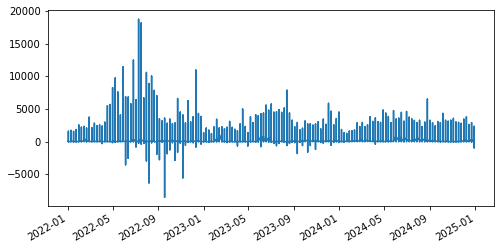

In [4]:
# 날짜 주기(frequency)를 명시적으로 지정해 경고를 제거
ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d')

ts.plot(figsize=(8,4)) #시각화

In [5]:
minus_sales_count = df[df['판매수량'] < 0].shape[0]
minus_sales_count

599